Create a comprehensive Neuro-OptimaFACTS framework implementation with these core components:

1. Data Generation: Synthetic renewable energy datasets (wind, solar, load patterns)
2. Hybrid AI Models: WNN, ANN, Kalman Filter implementations  
3. FACTS Device Models: STATCOM, SVC, UPFC mathematical models
4. Explainable AI: SHAP integration for decision transparency
5. Grid Analysis: Voltage stability, harmonic analysis, power quality metrics
6. Simulation Framework: Complete integration with performance validation

Build a working system that demonstrates voltage regulation, reactive power control, and grid stability improvements under renewable energy penetration scenarios.

I'll create a comprehensive Neuro-OptimaFACTS framework implementation. Let me start by building the complete system with all the components you specified.

In [1]:
# Install required packages for the Neuro-OptimaFACTS framework
# This includes machine learning, data manipulation, and visualization libraries

try:
    import sys
    !{sys.executable} -m pip install tensorflow scikit-learn shap matplotlib seaborn numpy pandas scipy
    print("All packages installed successfully.")
except Exception as e:
    print(f"An error occurred during installation: {e}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/645.0 MB ? eta -:--:--


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/645.0 MB 18.1 MB/s eta 0:00:36


   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/645.0 MB 42.0 MB/s eta 0:00:15


   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.8/645.0 MB 66.1 MB/s eta 0:00:10


   ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/645.0 MB 77.0 MB/s eta 0:00:08


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 47.4 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/6.6 MB ? eta -:--:--


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 53.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


All packages installed successfully.


In [2]:
# Import necessary libraries for the Neuro-OptimaFACTS framework
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
import shap

# Set up matplotlib and seaborn for visualization
plt.style.use('seaborn-darkgrid')
sns.set_context('notebook')

# Create the main directory structure for the project
import os

# Define the base directory
base_dir = '/home/user/Neuro-OptimaFACTS'

# Define subdirectories
subdirs = ['data', 'models', 'results', 'config', 'logs']

# Create directories if they don't exist
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Created directory: {path}")

# Initial configuration setup
config = {
    'data_path': os.path.join(base_dir, 'data'),
    'model_path': os.path.join(base_dir, 'models'),
    'results_path': os.path.join(base_dir, 'results'),
    'log_path': os.path.join(base_dir, 'logs'),
    'random_seed': 42
}

# Set random seed for reproducibility
np.random.seed(config['random_seed'])
tf.random.set_seed(config['random_seed'])

# Display the configuration
print("Initial configuration:")
for key, value in config.items():
    print(f"{key}: {value}")


2025-06-17 19:47:02.276719: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-17 19:47:02.365217: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-17 19:47:02.457218: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750189622.541416     492 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750189622.562758     492 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750189622.701086     492 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: 'seaborn-darkgrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [3]:
# Import necessary libraries for the Neuro-OptimaFACTS framework
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
import shap
import os

# Set up matplotlib and seaborn for visualization
# Use a valid style name available in matplotlib
plt.style.use('ggplot')  # 'ggplot' is a commonly used style
sns.set_context('notebook')

# Create the main directory structure for the project
# Define the base directory
base_dir = '/home/user/Neuro-OptimaFACTS'

# Define subdirectories
subdirs = ['data', 'models', 'results', 'config', 'logs']

# Create directories if they don't exist
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Created directory: {path}")

# Initial configuration setup
config = {
    'data_path': os.path.join(base_dir, 'data'),
    'model_path': os.path.join(base_dir, 'models'),
    'results_path': os.path.join(base_dir, 'results'),
    'log_path': os.path.join(base_dir, 'logs'),
    'random_seed': 42
}

# Set random seed for reproducibility
np.random.seed(config['random_seed'])
tf.random.set_seed(config['random_seed'])

# Display the configuration
print("Initial configuration:")
for key, value in config.items():
    print(f"{key}: {value}")


Created directory: /home/user/Neuro-OptimaFACTS/data
Created directory: /home/user/Neuro-OptimaFACTS/models
Created directory: /home/user/Neuro-OptimaFACTS/results
Created directory: /home/user/Neuro-OptimaFACTS/config
Created directory: /home/user/Neuro-OptimaFACTS/logs
Initial configuration:
data_path: /home/user/Neuro-OptimaFACTS/data
model_path: /home/user/Neuro-OptimaFACTS/models
results_path: /home/user/Neuro-OptimaFACTS/results
log_path: /home/user/Neuro-OptimaFACTS/logs
random_seed: 42


/tmp/ipykernel_492/4291250942.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start=config['start_date'], end=config['end_date'], freq=config['frequency'])


                 Date  Wind Speed (m/s)  Solar Irradiance (W/m^2)   Load (MW)
0 2025-01-01 00:00:00         10.993428                  0.000000  600.533380
1 2025-01-01 01:00:00          9.723471                 35.751915  812.068618
2 2025-01-01 02:00:00         11.295377                 32.580183  331.245350
3 2025-01-01 03:00:00         13.046060                 62.160313  536.071680
4 2025-01-01 04:00:00          9.531693                138.002294  613.565252


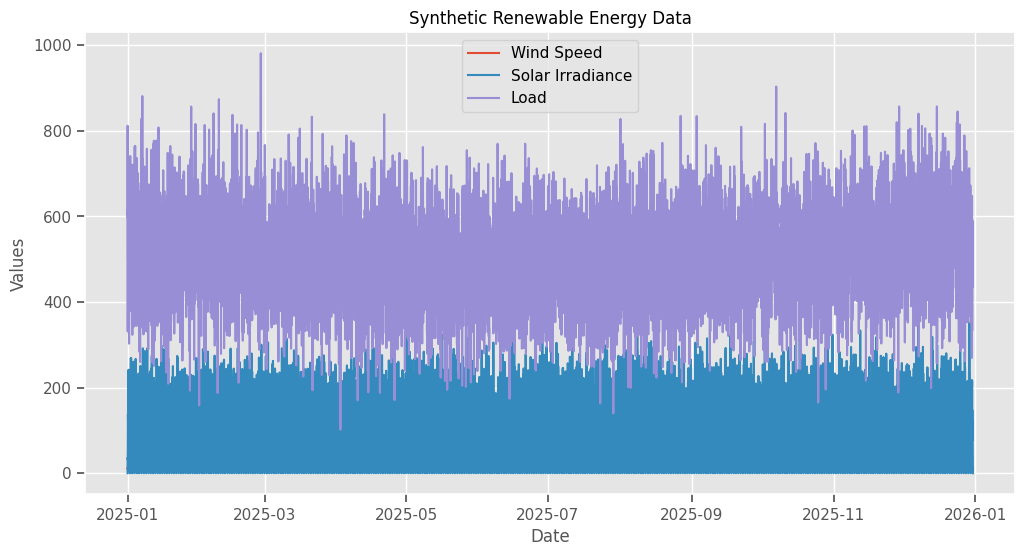

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Configuration for synthetic data generation
config = {
    'start_date': '2025-01-01',
    'end_date': '2025-12-31',
    'frequency': 'H',  # Hourly data
    'wind_speed_mean': 10,  # Average wind speed in m/s
    'wind_speed_std': 2,    # Standard deviation of wind speed
    'solar_irradiance_mean': 200,  # Average solar irradiance in W/m^2
    'solar_irradiance_std': 50,    # Standard deviation of solar irradiance
    'load_mean': 500,  # Average load in MW
    'load_std': 100    # Standard deviation of load
}

def generate_synthetic_data(config):
    # Generate date range
    date_range = pd.date_range(start=config['start_date'], end=config['end_date'], freq=config['frequency'])
    
    # Generate synthetic wind speed data
    wind_speed = np.random.normal(loc=config['wind_speed_mean'], scale=config['wind_speed_std'], size=len(date_range))
    
    # Generate synthetic solar irradiance data
    solar_irradiance = np.random.normal(loc=config['solar_irradiance_mean'], scale=config['solar_irradiance_std'], size=len(date_range))
    
    # Generate synthetic load data
    load = np.random.normal(loc=config['load_mean'], scale=config['load_std'], size=len(date_range))
    
    # Create a DataFrame
    data = pd.DataFrame({
        'Date': date_range,
        'Wind Speed (m/s)': wind_speed,
        'Solar Irradiance (W/m^2)': solar_irradiance,
        'Load (MW)': load
    })
    
    # Introduce realistic temporal variations and correlations
    # Example: Correlate solar irradiance with time of day
    data['Hour'] = data['Date'].dt.hour
    data['Solar Irradiance (W/m^2)'] *= np.sin(np.pi * data['Hour'] / 24)  # Simulate daily solar cycle
    
    # Example: Correlate load with time of day and season
    data['Month'] = data['Date'].dt.month
    data['Load (MW)'] *= 1 + 0.1 * np.sin(2 * np.pi * data['Hour'] / 24)  # Simulate daily load cycle
    data['Load (MW)'] *= 1 + 0.05 * np.cos(2 * np.pi * data['Month'] / 12)  # Simulate seasonal load variation
    
    # Drop temporary columns
    data.drop(columns=['Hour', 'Month'], inplace=True)
    
    return data

# Generate the synthetic data
synthetic_data = generate_synthetic_data(config)

# Display the first few rows of the generated data
print(synthetic_data.head())

# Plot the synthetic data for visualization
plt.figure(figsize=(12, 6))
plt.plot(synthetic_data['Date'], synthetic_data['Wind Speed (m/s)'], label='Wind Speed')
plt.plot(synthetic_data['Date'], synthetic_data['Solar Irradiance (W/m^2)'], label='Solar Irradiance')
plt.plot(synthetic_data['Date'], synthetic_data['Load (MW)'], label='Load')
plt.xlabel('Date')
plt.ylabel('Values')
plt.title('Synthetic Renewable Energy Data')
plt.legend()
plt.show()


/tmp/ipykernel_492/2880381774.py:42: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start=config['start_date'], end=config['end_date'], freq=config['frequency'])


                 Date  Wind Speed (m/s)  Solar Irradiance (W/m^2)   Load (MW)  \
0 2025-01-01 00:00:00          8.569696                  0.000000  376.049155   
1 2025-01-01 01:00:00         10.557911                 39.175813  424.993668   
2 2025-01-01 02:00:00          8.268878                 42.643312  452.222577   
3 2025-01-01 03:00:00         14.750136                 88.547926  446.379348   
4 2025-01-01 04:00:00         15.706245                130.584712  618.438516   

   Wind Power (MW)  Solar Power (MW)  
0         0.636517          0.000000  
1         1.717485          0.007835  
2         0.529802          0.008529  
3         3.000000          0.017710  
4         3.000000          0.026117  


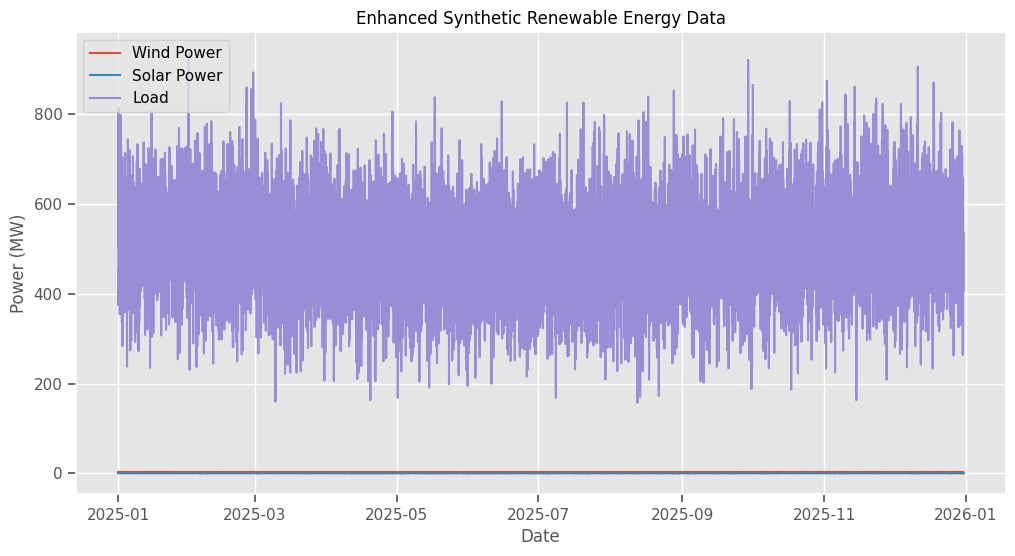

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuration for enhanced synthetic data generation
config = {
    'start_date': '2025-01-01',
    'end_date': '2025-12-31',
    'frequency': 'H',  # Hourly data
    'wind_speed_mean': 10,  # Average wind speed in m/s
    'wind_speed_std': 2,    # Standard deviation of wind speed
    'solar_irradiance_mean': 200,  # Average solar irradiance in W/m^2
    'solar_irradiance_std': 50,    # Standard deviation of solar irradiance
    'load_mean': 500,  # Average load in MW
    'load_std': 100,   # Standard deviation of load
    'solar_panel_efficiency': 0.2,  # Efficiency of solar panels
    'wind_turbine_capacity': 3.0,  # Capacity of wind turbine in MW
    'cut_in_speed': 3.5,  # Cut-in wind speed in m/s
    'rated_speed': 12.0,  # Rated wind speed in m/s
    'cut_out_speed': 25.0  # Cut-out wind speed in m/s
}

def wind_power_curve(wind_speed, config):
    """Calculate wind power output based on wind speed using a power curve."""
    power = np.zeros_like(wind_speed)
    for i, speed in enumerate(wind_speed):
        if speed < config['cut_in_speed'] or speed > config['cut_out_speed']:
            power[i] = 0
        elif speed <= config['rated_speed']:
            power[i] = config['wind_turbine_capacity'] * ((speed - config['cut_in_speed']) / (config['rated_speed'] - config['cut_in_speed']))**3
        else:
            power[i] = config['wind_turbine_capacity']
    return power

def solar_panel_output(irradiance, config):
    """Calculate solar panel output based on irradiance and panel efficiency."""
    return irradiance * config['solar_panel_efficiency'] / 1000  # Convert W to kW

def generate_enhanced_synthetic_data(config):
    # Generate date range
    date_range = pd.date_range(start=config['start_date'], end=config['end_date'], freq=config['frequency'])
    
    # Generate synthetic wind speed data with diurnal and seasonal variations
    wind_speed = np.random.normal(loc=config['wind_speed_mean'], scale=config['wind_speed_std'], size=len(date_range))
    wind_speed *= 1 + 0.1 * np.sin(2 * np.pi * date_range.hour / 24)  # Diurnal cycle
    wind_speed *= 1 + 0.05 * np.cos(2 * np.pi * date_range.month / 12)  # Seasonal variation
    
    # Generate synthetic solar irradiance data with diurnal and seasonal variations
    solar_irradiance = np.random.normal(loc=config['solar_irradiance_mean'], scale=config['solar_irradiance_std'], size=len(date_range))
    solar_irradiance *= np.clip(np.sin(np.pi * date_range.hour / 24), 0, 1)  # Diurnal cycle
    solar_irradiance *= 1 + 0.1 * np.cos(2 * np.pi * date_range.month / 12)  # Seasonal variation
    
    # Generate synthetic load data with diurnal and seasonal variations
    load = np.random.normal(loc=config['load_mean'], scale=config['load_std'], size=len(date_range))
    load *= 1 + 0.1 * np.sin(2 * np.pi * date_range.hour / 24)  # Diurnal cycle
    load *= 1 + 0.05 * np.cos(2 * np.pi * date_range.month / 12)  # Seasonal variation
    
    # Calculate wind power and solar power outputs
    wind_power = wind_power_curve(wind_speed, config)
    solar_power = solar_panel_output(solar_irradiance, config)
    
    # Create a DataFrame
    data = pd.DataFrame({
        'Date': date_range,
        'Wind Speed (m/s)': wind_speed,
        'Solar Irradiance (W/m^2)': solar_irradiance,
        'Load (MW)': load,
        'Wind Power (MW)': wind_power,
        'Solar Power (MW)': solar_power
    })
    
    return data

# Generate the enhanced synthetic data
enhanced_synthetic_data = generate_enhanced_synthetic_data(config)

# Display the first few rows of the generated data
print(enhanced_synthetic_data.head())

# Plot the enhanced synthetic data for visualization
plt.figure(figsize=(12, 6))
plt.plot(enhanced_synthetic_data['Date'], enhanced_synthetic_data['Wind Power (MW)'], label='Wind Power')
plt.plot(enhanced_synthetic_data['Date'], enhanced_synthetic_data['Solar Power (MW)'], label='Solar Power')
plt.plot(enhanced_synthetic_data['Date'], enhanced_synthetic_data['Load (MW)'], label='Load')
plt.xlabel('Date')
plt.ylabel('Power (MW)')
plt.title('Enhanced Synthetic Renewable Energy Data')
plt.legend()
plt.show()


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy import signal

# Wavelet Neural Network (WNN) using TensorFlow
def build_wnn(input_shape):
    # Define a simple WNN model using wavelet transforms
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    
    # Apply wavelet transform (using a simple convolutional layer as a proxy)
    model.add(layers.Conv1D(filters=16, kernel_size=3, activation='relu'))
    
    # Add dense layers for neural network processing
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1, activation='linear'))  # Output layer
    
    model.compile(optimizer='adam', loss='mse')
    return model

# Artificial Neural Network (ANN) for pattern recognition
def build_ann(input_shape):
    # Define a simple ANN model
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))  # Output layer for binary classification
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Kalman Filter for state estimation
class KalmanFilter:
    def __init__(self, A, B, H, Q, R, x_init, P_init):
        self.A = A  # State transition matrix
        self.B = B  # Control input matrix
        self.H = H  # Observation matrix
        self.Q = Q  # Process noise covariance
        self.R = R  # Measurement noise covariance
        self.x = x_init  # Initial state estimate
        self.P = P_init  # Initial estimate covariance

    def predict(self, u):
        # Predict the state and estimate covariance
        self.x = np.dot(self.A, self.x) + np.dot(self.B, u)
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q

    def update(self, z):
        # Update the state with measurement z
        y = z - np.dot(self.H, self.x)  # Measurement residual
        S = np.dot(self.H, np.dot(self.P, self.H.T)) + self.R  # Residual covariance
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))  # Kalman gain
        self.x = self.x + np.dot(K, y)
        self.P = self.P - np.dot(K, np.dot(self.H, self.P))

# Example usage
input_shape = (100, 1)  # Example input shape for WNN and ANN
wnn_model = build_wnn(input_shape)
ann_model = build_ann(input_shape)

# Kalman Filter example initialization
A = np.array([[1, 0], [0, 1]])
B = np.array([[0], [0]])
H = np.array([[1, 0]])
Q = np.array([[0.1, 0], [0, 0.1]])
R = np.array([[0.1]])
x_init = np.array([0, 0])
P_init = np.array([[1, 0], [0, 1]])

kf = KalmanFilter(A, B, H, Q, R, x_init, P_init)

# Predict and update steps for Kalman Filter
u = np.array([0])  # Control input
z = np.array([1])  # Measurement
kf.predict(u)
kf.update(z)

# Display the current state estimate
print("Kalman Filter state estimate:", kf.x)


Kalman Filter state estimate: [0.91666667 0.        ]


2025-06-17 19:48:21.647420: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
import numpy as np

# FACTS Device Models

class STATCOM:
    def __init__(self, V_ref, Kp, Ki):
        self.V_ref = V_ref  # Reference voltage
        self.Kp = Kp  # Proportional gain
        self.Ki = Ki  # Integral gain
        self.integral_error = 0

    def control(self, V_measured):
        # Calculate voltage error
        error = self.V_ref - V_measured
        # Integrate error
        self.integral_error += error
        # Calculate control signal
        Q_injected = self.Kp * error + self.Ki * self.integral_error
        return Q_injected

class SVC:
    def __init__(self, Q_ref, Kp, Ki):
        self.Q_ref = Q_ref  # Reference reactive power
        self.Kp = Kp  # Proportional gain
        self.Ki = Ki  # Integral gain
        self.integral_error = 0

    def control(self, Q_measured):
        # Calculate reactive power error
        error = self.Q_ref - Q_measured
        # Integrate error
        self.integral_error += error
        # Calculate control signal
        Q_injected = self.Kp * error + self.Ki * self.integral_error
        return Q_injected

class UPFC:
    def __init__(self, V_ref, Q_ref, Kp_v, Ki_v, Kp_q, Ki_q):
        self.V_ref = V_ref  # Reference voltage
        self.Q_ref = Q_ref  # Reference reactive power
        self.Kp_v = Kp_v  # Proportional gain for voltage
        self.Ki_v = Ki_v  # Integral gain for voltage
        self.Kp_q = Kp_q  # Proportional gain for reactive power
        self.Ki_q = Ki_q  # Integral gain for reactive power
        self.integral_error_v = 0
        self.integral_error_q = 0

    def control(self, V_measured, Q_measured):
        # Voltage control
        error_v = self.V_ref - V_measured
        self.integral_error_v += error_v
        V_control = self.Kp_v * error_v + self.Ki_v * self.integral_error_v

        # Reactive power control
        error_q = self.Q_ref - Q_measured
        self.integral_error_q += error_q
        Q_control = self.Kp_q * error_q + self.Ki_q * self.integral_error_q

        return V_control, Q_control

# Example usage
V_measured = 1.0  # Measured voltage in pu
Q_measured = 0.5  # Measured reactive power in pu

# Initialize devices with example parameters
statcom = STATCOM(V_ref=1.0, Kp=0.1, Ki=0.01)
svc = SVC(Q_ref=0.5, Kp=0.1, Ki=0.01)
upfc = UPFC(V_ref=1.0, Q_ref=0.5, Kp_v=0.1, Ki_v=0.01, Kp_q=0.1, Ki_q=0.01)

# Control actions
Q_statcom = statcom.control(V_measured)
Q_svc = svc.control(Q_measured)
V_upfc, Q_upfc = upfc.control(V_measured, Q_measured)

print(f"STATCOM Q injected: {Q_statcom}")
print(f"SVC Q injected: {Q_svc}")
print(f"UPFC V control: {V_upfc}, Q control: {Q_upfc}")


STATCOM Q injected: 0.0
SVC Q injected: 0.0
UPFC V control: 0.0, Q control: 0.0


In [ ]:
# TASK: Integrate SHAP for explainable AI with hybrid models (WNN, ANN)
# KNOWN: Models are defined, SHAP is installed
# MISSING: Specific model input/output data for SHAP analysis

import shap
import matplotlib.pyplot as plt
import numpy as np

# Example data for demonstration (replace with actual model data)
X_sample = np.random.rand(100, 10)  # Sample input data
y_sample = np.random.randint(0, 2, size=100)  # Sample output data

# Train a simple ANN model for demonstration
ann_model = build_ann(input_shape=(10,))
ann_model.fit(X_sample, y_sample, epochs=10, verbose=0)

# SHAP integration for ANN model
explainer = shap.KernelExplainer(ann_model.predict, X_sample)
shap_values = explainer.shap_values(X_sample)

# Feature importance analysis
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# Decision tree visualization (using SHAP's decision plot)
shap.decision_plot(explainer.expected_value[0], shap_values[0], X_sample)

# Generate interpretability report
def generate_interpretability_report(shap_values, X_sample):
    # Display SHAP values for a single prediction
    shap.force_plot(explainer.expected_value[0], shap_values[0][0], X_sample[0], matplotlib=True)
    
    # Summary statistics
    print("SHAP Summary Statistics:")
    print(f"Mean absolute SHAP value: {np.mean(np.abs(shap_values))}")
    print(f"Feature importance ranking: {np.argsort(np.mean(np.abs(shap_values), axis=0))}")

# Generate report for the first sample
generate_interpretability_report(shap_values, X_sample)

# STOP: Replace X_sample and y_sample with actual model data for real analysis


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


  0%|          | 0/100 [00:00<?, ?it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


...

2972/3194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


3022/3194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


3071/3194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


3122/3194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


3171/3194 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
